In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [90]:
data_df = pd.read_csv('data.csv')
data_df = data_df.dropna(subset=['Count'])
data_df

,Date,Name,Count,Point
0,2025-06-01,Аманн,0,БЛУМ
1,2025-06-02,Аманн,0,БЛУМ
2,2025-06-03,Аманн,0,БЛУМ
3,2025-06-04,Аманн,0,БЛУМ
4,2025-06-05,Аманн,0,БЛУМ
...,...,...,...,...
49197,2026-07-04,Фокачча 400х600,8,СПЕЦ_26
49211,2026-07-18,Фокачча 400х600,2,СПЕЦ_26
49473,2026-07-04,Фокачча GN 2/3,2,СПЕЦ_26
51134,2026-07-09,Морнинг бан жасмин,5,СПЕЦ_26


In [91]:
data_df[data_df['Name'] == 'Бабка корица и карамель']

,Date,Name,Count,Point
276,2025-06-01,Бабка корица и карамель,2,БЛУМ
277,2025-06-02,Бабка корица и карамель,1,БЛУМ
278,2025-06-03,Бабка корица и карамель,1,БЛУМ
279,2025-06-04,Бабка корица и карамель,1,БЛУМ
280,2025-06-05,Бабка корица и карамель,1,БЛУМ
...,...,...,...,...
44613,2026-07-20,Бабка корица и карамель,1,СПЕЦ_26
44623,2026-07-30,Бабка корица и карамель,3,СПЕЦ_26
44624,2026-07-31,Бабка корица и карамель,3,СПЕЦ_26
44625,2026-08-01,Бабка корица и карамель,1,СПЕЦ_26


In [92]:
data_df['Date'] = pd.to_datetime(data_df['Date'], errors='coerce')
data_df['Date'].dtype

dtype('<M8[ns]')

In [93]:
data_df['Count'] = pd.to_numeric(data_df['Count'], errors='coerce').fillna(0)

In [94]:
df_2025 = data_df[data_df['Date'].dt.year == 2025].copy()
df_2025

,Date,Name,Count,Point
0,2025-06-01,Аманн,0.0,БЛУМ
1,2025-06-02,Аманн,0.0,БЛУМ
2,2025-06-03,Аманн,0.0,БЛУМ
3,2025-06-04,Аманн,0.0,БЛУМ
4,2025-06-05,Аманн,0.0,БЛУМ
...,...,...,...,...
42742,2025-06-19,Morning bun цедра - кардамон,6.0,СПЕЦ_25
42743,2025-06-20,Morning bun цедра - кардамон,6.0,СПЕЦ_25
42744,2025-06-21,Morning bun цедра - кардамон,6.0,СПЕЦ_25
42745,2025-06-22,Morning bun цедра - кардамон,6.0,СПЕЦ_25


In [95]:
point_sales = df_2025.groupby('Point')['Count'].sum().sort_values(ascending=False)
print("--- 1. КАК ТОВАР РАСПРЕДЕЛЯЕТСЯ МЕЖДУ ТОЧКАМИ? ---")
print(point_sales)
print(f"Всего: {df_2025['Count'].sum()}")
print("\n" + "="*60 + "\n")

--- 1. КАК ТОВАР РАСПРЕДЕЛЯЕТСЯ МЕЖДУ ТОЧКАМИ? ---
Point
ЦЕХ_2025       23118.0
МАЯК            6163.0
ЧАПА_2025       5098.0
БЛУМ            5084.0
Эрна            3197.0
СПЕЦ_25         2230.0
КМ20            1454.0
Тото            1358.0
DODGY           1213.0
Салют            866.0
Pshur            573.0
Bitter Drop      452.0
Чехов и ко       389.0
Полдень          205.0
UCLAD SPACE      112.0
Энтузиаст         55.0
Name: Count, dtype: float64
Всего: 51567.0




In [96]:
print("--- 2. ТОП-3 ТОВАРОВ ДЛЯ КАЖДОЙ ТОРГОВОЙ ТОЧКИ ---")
top_by_point = df_2025.groupby(['Point', 'Name'])['Count'].sum().reset_index()
top_by_point = top_by_point.sort_values(['Point', 'Count'], ascending =[True, False])
print(top_by_point.groupby('Point').head(3).to_string(index=False))

--- 2. ТОП-3 ТОВАРОВ ДЛЯ КАЖДОЙ ТОРГОВОЙ ТОЧКИ ---
      Point                                        Name  Count
Bitter Drop                                 Тартин 0,75  356.0
Bitter Drop                               Тартин гречка   96.0
      DODGY                             Фокачча 400х600 1149.0
      DODGY                                    Доставка   64.0
      Pshur                                 Тартин 0,75  144.0
      Pshur                                Круассан 75г   97.0
      Pshur                             Булка с корицей   95.0
UCLAD SPACE            Синнабоны шоколад-пекан-карамель   42.0
UCLAD SPACE                             Булка с корицей   28.0
UCLAD SPACE                Morning bun цедра - кардамон   21.0
       БЛУМ                 Печенье на закваске шоколад 1260.0
       БЛУМ Бриошь с ванильным кремом в ягодной глазури  928.0
       БЛУМ                              Шу мини жасмин  796.0
       КМ20                          Бриошь для бургера  759.0
    

Деление (Финальный средний балл): Полученную сумму он делит на общее количество строк, которые попали в этот фильтр.
$$ \text{Среднее значение ячейки} = \frac{\text{Сумма всех продаж для дня недели на точке}}{\text{Количество строк для дня недели на точке}} $$


In [97]:
print(" ---3. Сезонность в какие дни больше продаётся")
df_2025['Day_of_week'] = df_2025['Date'].dt.day_name()
weekly_pattern = df_2025.pivot_table(
    index = 'Day_of_week',
    columns='Point',
    values='Count',
    aggfunc='mean'
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

short_days = {
'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР', 'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday':'ВС'
}
weekly_pattern.index.map(short_days)

print(weekly_pattern)

 ---3. Сезонность в какие дни больше продаётся
Point        Bitter Drop      DODGY     Pshur  UCLAD SPACE      БЛУМ  \
Day_of_week                                                            
Monday          5.000000   9.444444  2.566667     4.090909  0.950226   
Tuesday         5.000000   8.166667  2.464286     4.000000  0.755656   
Wednesday       4.875000   9.500000  2.464286          NaN  0.660633   
Thursday        5.000000   9.833333  2.428571     4.000000  0.703620   
Friday          5.000000   9.944444  2.464286          NaN  0.798643   
Saturday        5.000000   9.388889  3.571429     4.250000  0.789593   
Sunday          5.333333  10.000000  3.457143     4.500000  1.014706   

Point            КМ20      МАЯК   Полдень   СПЕЦ_25     Салют      Тото  \
Day_of_week                                                               
Monday       7.764706  4.413174  3.428571  8.000000  0.273077  4.888889   
Tuesday      8.200000  4.362069  3.500000  6.864865  0.507692  4.606061   
Wedn

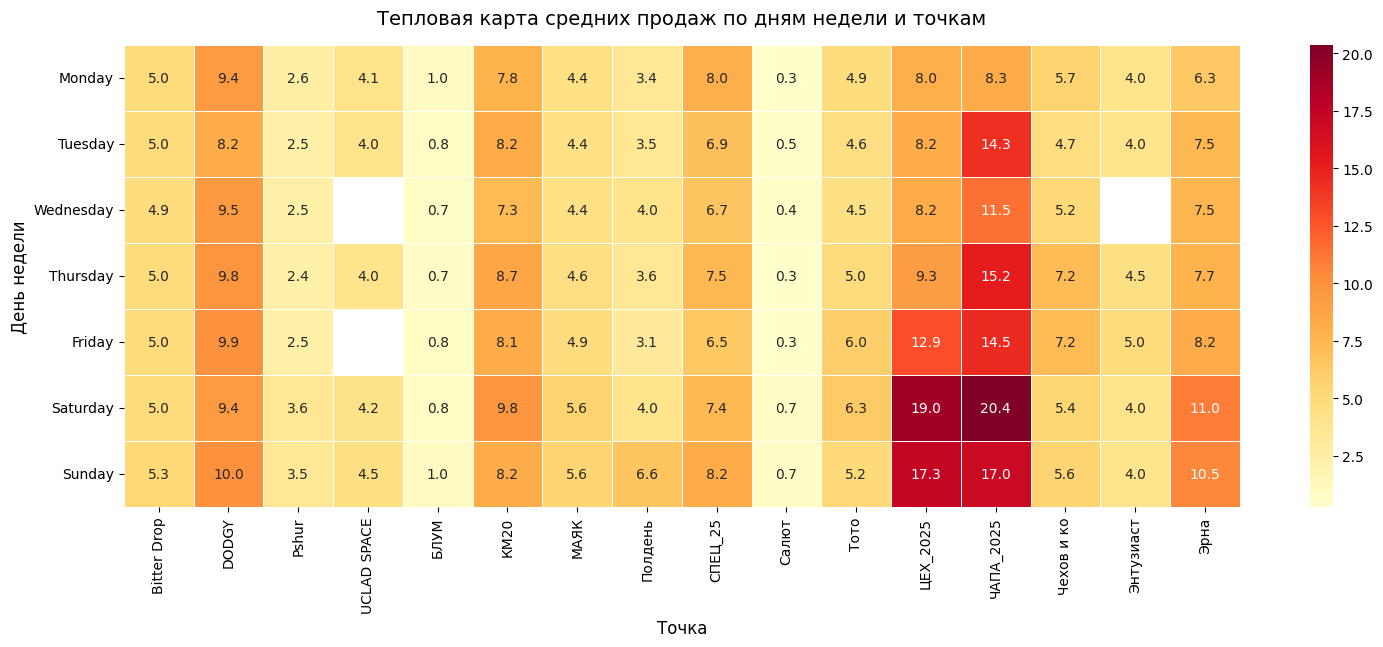

In [98]:
plt.figure(figsize=(18, 6))
sns.heatmap(weekly_pattern, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Тепловая карта средних продаж по дням недели и точкам', fontsize=14, pad=15)
plt.ylabel('День недели', fontsize=12)
plt.xlabel('Точка', fontsize=12)
# plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\4074253994.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_total.index, y=weekly_total.values, palette='YlOrRd')


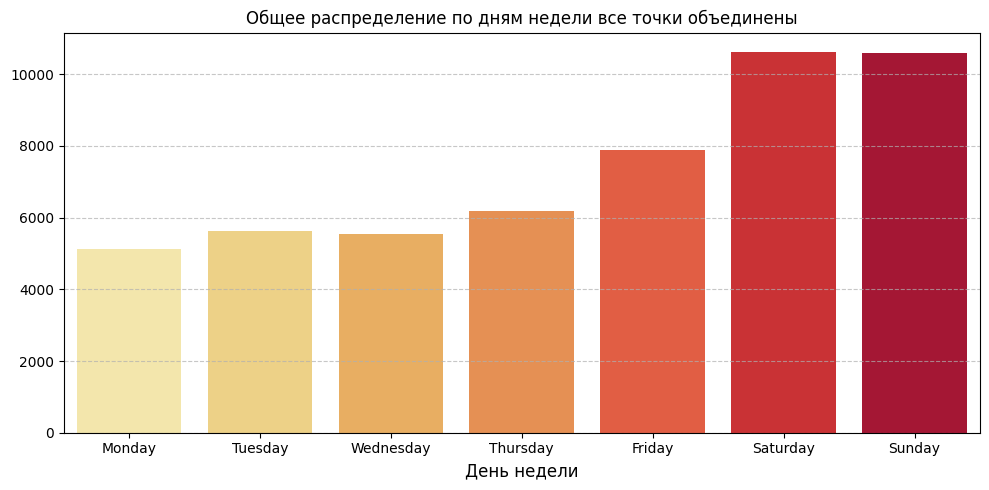

In [99]:
weekly_total = df_2025.groupby('Day_of_week')['Count'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

short_days = {
'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР', 'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday':'ВС'
}
weekly_pattern.index.map(short_days)

plt.figure(figsize=(10, 5))

sns.barplot(x=weekly_total.index, y=weekly_total.values, palette='YlOrRd')
plt.title('Общее распределение по дням недели все точки объединены', fontsize=12)
plt.xlabel('День недели', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Pr

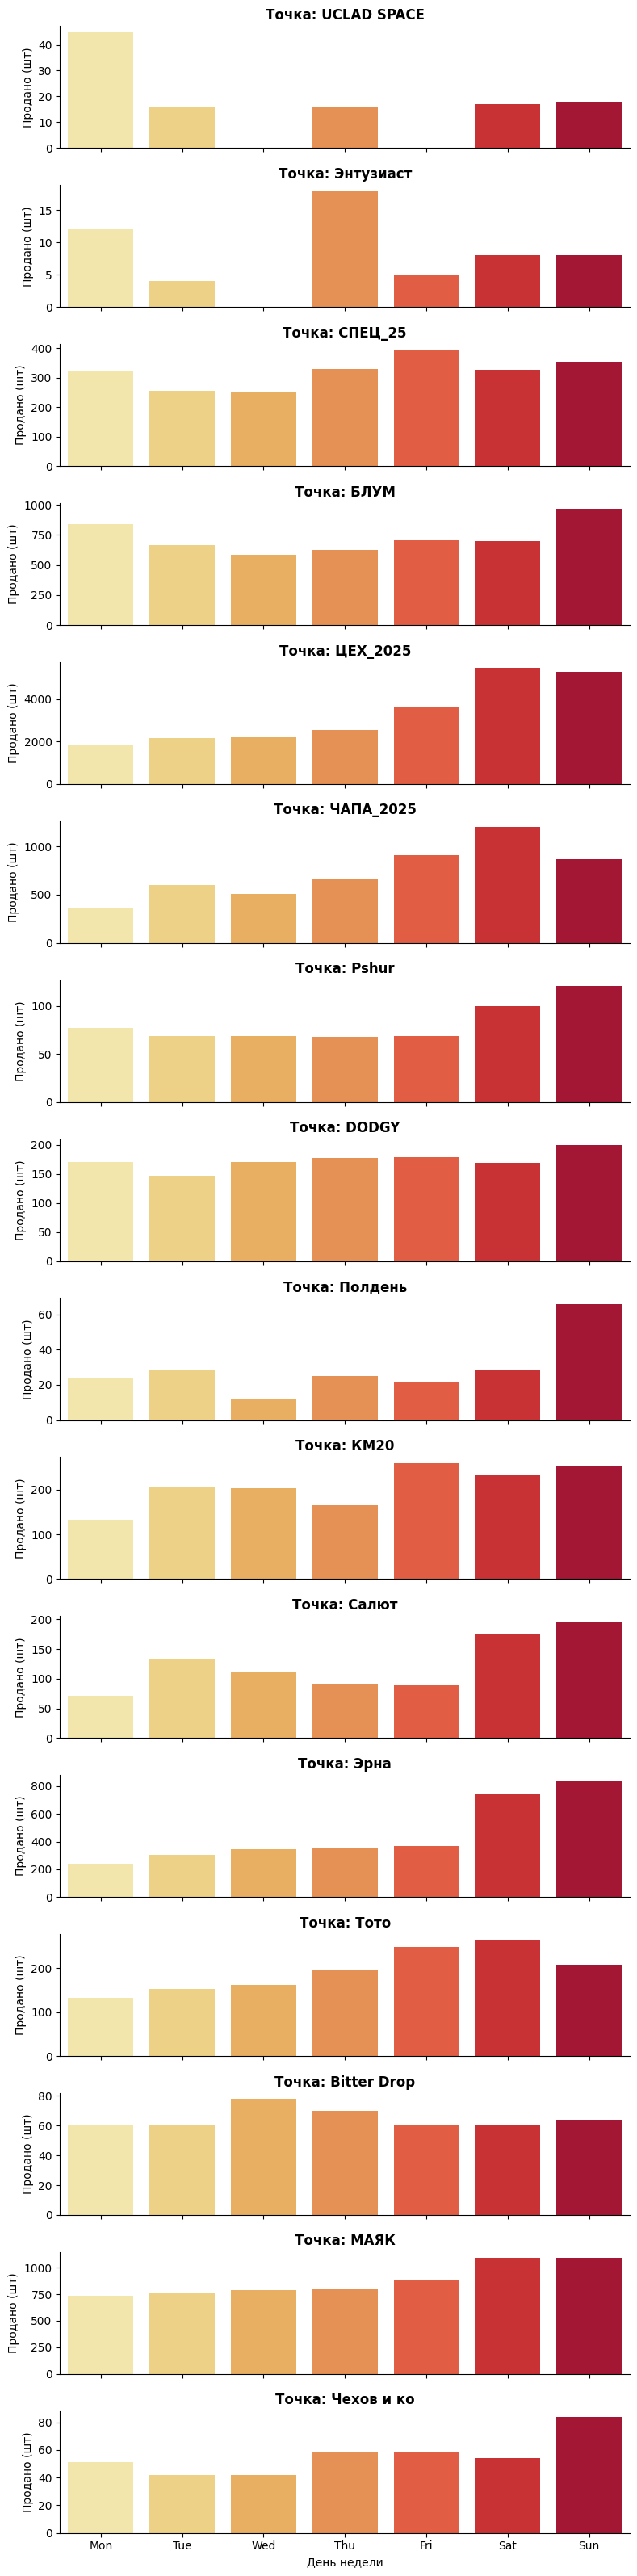

In [100]:
# 1. Считаем сумму продаж для каждого сочетания Точка + День недели
df_grouped = df_2025.groupby(['Point', 'Day_of_week'])['Count'].sum().reset_index()

# 2. Приводим дни недели к короткому виду и сортируем строго от Mon до Sun
short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
df_grouped['Day_of_week'] = df_grouped['Day_of_week'].map(short_days)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_grouped['Day_of_week'] = pd.Categorical(df_grouped['Day_of_week'], categories=day_order, ordered=True)
df_grouped = df_grouped.sort_values('Day_of_week')

# 3. Настраиваем сетку графиков: col_wrap=1 заставляет графики строиться построчно (в 1 колонку)
# sharey=False важно, чтобы у мелких точек график не превратился в плоскую линию из-за гигантов типа ЦЕХ
g = sns.FacetGrid(df_grouped, row="Point", aspect=4, height=2, sharey=False)

# 4. Заливаем в сетку наши гистограммы (столбчатые диаграммы)
g.map_dataframe(sns.barplot, x="Day_of_week", y="Count", palette="YlOrRd")

# Красиво оформляем оси и заголовки для каждой строки
g.set_titles(row_template="Точка: {row_name}", size=12, weight='bold')
g.set_axis_labels("День недели", "Продано (шт)")

plt.tight_layout()
plt.show()

c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\S_V_Nikitin\AppData\Local\Pr

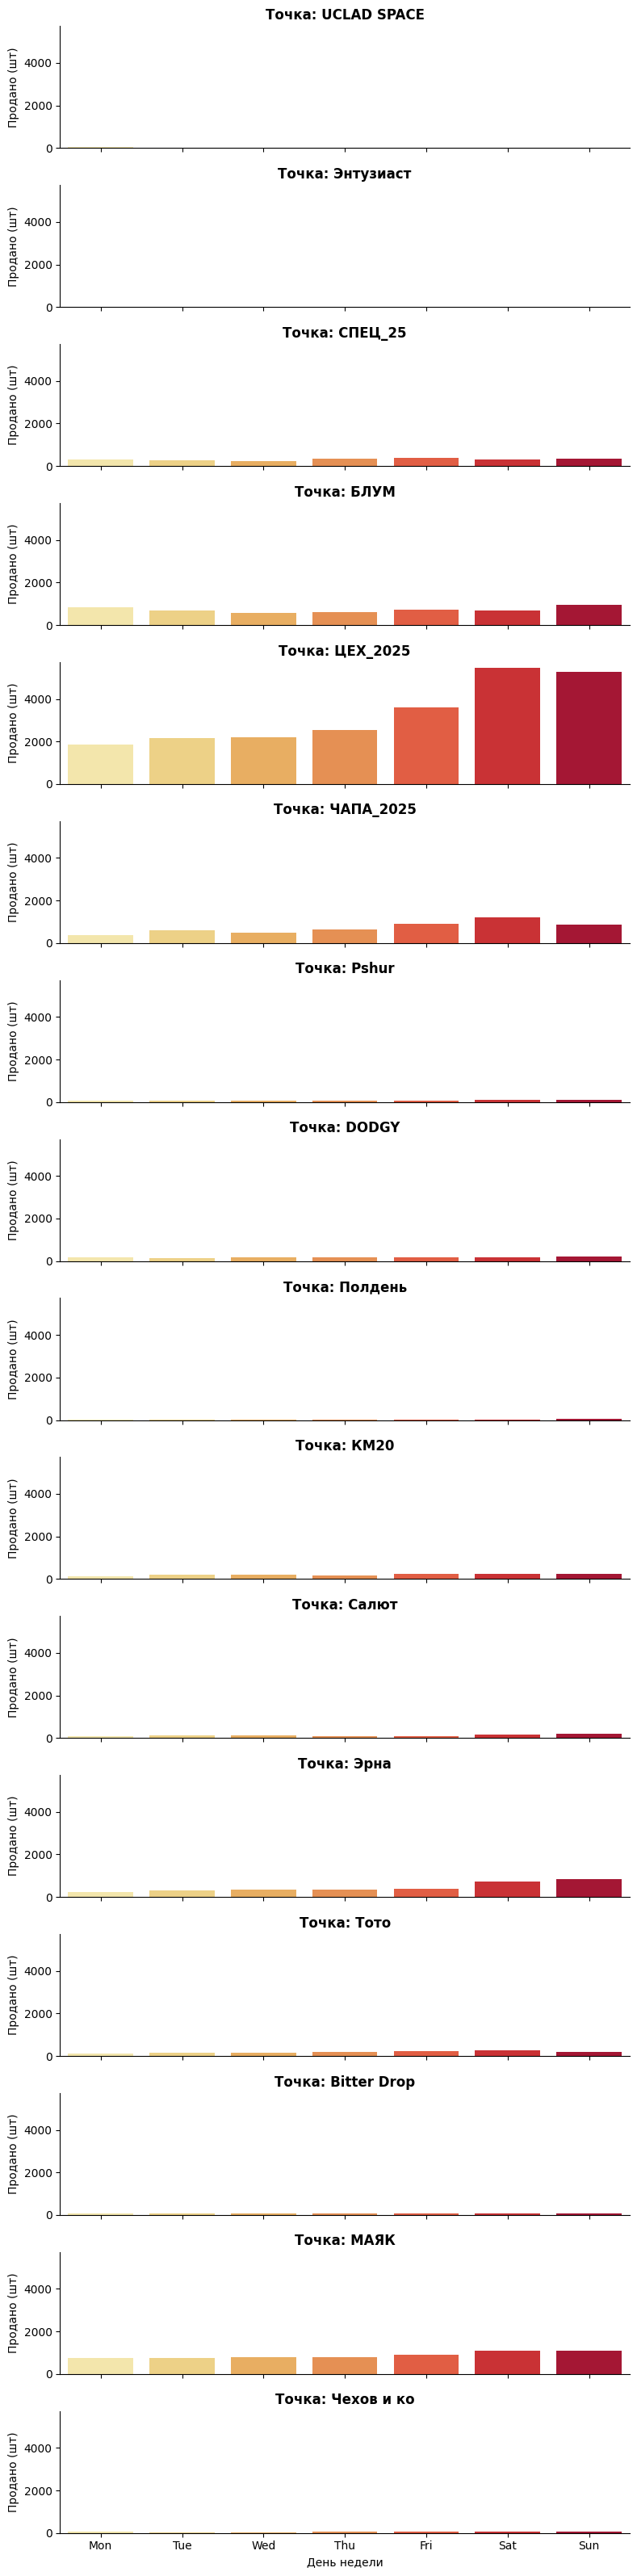

In [101]:

df_grouped = df_2025.groupby(['Point', 'Day_of_week'])['Count'].sum().reset_index()

# 2. Приводим дни недели к короткому виду и сортируем строго от Mon до Sun
short_days = {'Monday': 'Mon', 'Tuesday': 'Tue', 'Wednesday': 'Wed', 'Thursday': 'Thu', 'Friday': 'Fri', 'Saturday': 'Sat', 'Sunday': 'Sun'}
df_grouped['Day_of_week'] = df_grouped['Day_of_week'].map(short_days)

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_grouped['Day_of_week'] = pd.Categorical(df_grouped['Day_of_week'], categories=day_order, ordered=True)
df_grouped = df_grouped.sort_values('Day_of_week')

# 3. Настраиваем сетку графиков: col_wrap=1 заставляет графики строиться построчно (в 1 колонку)
# sharey=False важно, чтобы у мелких точек график не превратился в плоскую линию из-за гигантов типа ЦЕХ
g = sns.FacetGrid(df_grouped, row="Point", aspect=4, height=2, sharey=True)

# 4. Заливаем в сетку наши гистограммы (столбчатые диаграммы)
g.map_dataframe(sns.barplot, x="Day_of_week", y="Count", palette="YlOrRd")

# Красиво оформляем оси и заголовки для каждой строки
g.set_titles(row_template="Точка: {row_name}", size=12, weight='bold')
g.set_axis_labels("День недели", "Продано (шт)")

plt.tight_layout()
plt.show()

Мы проверям насколько данные однородны.  
Допустим у нас есть какая то позиция, которая продаётся в один магазин, в большом колличестве (например печенье)
Если такие позиции имеются, без фильтрации данных сложнее интерпретировать графики связанные с общим колличеством всех товаров

In [102]:
product_totals = df_2025.groupby('Name')['Count'].sum().sort_values(ascending=False).to_frame()

total_volume = product_totals['Count'].sum()
product_totals['Share_%'] = (product_totals['Count'] / total_volume) * 100
product_totals['Cumulative_Share_%'] = product_totals['Share_%'].cumsum()
print('TOP 10 по общему объему')
print(product_totals.head(10).to_string())

max_item = product_totals['Count'].max()
median_item = product_totals['Count'].median()
anomaly_ratio = max_item / median_item if median_item > 0 else 0

print(f"Метрика однородности: Самый продаваемый товар превышает МЕДИАННЫЙ товар в {anomaly_ratio:.1f})")

if anomaly_ratio > 50:
    print("КРАЙНЕ НЕОДНОРОДНА")
else:
    print("Структура данных однородна")

TOP 10 по общему объему
                                   Count   Share_%  Cumulative_Share_%
Name                                                                  
Булка с корицей                   4003.0  7.762716            7.762716
Бейгл 100                         3985.0  7.727810           15.490527
Круассан 75г                      3660.0  7.097562           22.588089
Тартин 0,75                       2829.0  5.486067           28.074156
Булка с кардамоном                2583.0  5.009017           33.083173
Булка с маком                     2548.0  4.941145           38.024318
Маритоццо ваниль-мисо карамель    2267.0  4.396222           42.420540
Синнабоны шоколад-пекан-карамель  2253.0  4.369073           46.789614
Печенье на закваске шоколад       1999.0  3.876510           50.666124
Аманн                             1937.0  3.756278           54.422402
Метрика однородности: Самый продаваемый товар превышает МЕДИАННЫЙ товар в 32.8)
Структура данных однородна


In [103]:
categories_df = pd.read_csv('categories.csv')
categories_df

,Name,Category,Status
0,Аманн,Булки,Активный
1,Аманн Черный кунжут,Булки,Снят
2,Бабка Кардамон,Булки,Снят
3,Бабка Корица,Булки,Снят
4,Бабка корица и карамель,Булки,Активный
...,...,...,...
194,Горчица пф,Полуфабрикаты,пф
195,Квашеная капуста пф,Полуфабрикаты,пф
196,Ханни баттер тост,Десерты,Снят
197,Морнинг бан жасмин,Булки,Активный


In [104]:
df_2025 = pd.merge(df_2025, categories_df, on='Name', how='left')
df_2025

,Date,Name,Count,Point,Day_of_week,Category,Status
0,2025-06-01,Аманн,0.0,БЛУМ,Sunday,Булки,Активный
1,2025-06-02,Аманн,0.0,БЛУМ,Monday,Булки,Активный
2,2025-06-03,Аманн,0.0,БЛУМ,Tuesday,Булки,Активный
3,2025-06-04,Аманн,0.0,БЛУМ,Wednesday,Булки,Активный
4,2025-06-05,Аманн,0.0,БЛУМ,Thursday,Булки,Активный
...,...,...,...,...,...,...,...
13307,2025-06-19,Morning bun цедра - кардамон,6.0,СПЕЦ_25,Thursday,Булки,Снят
13308,2025-06-20,Morning bun цедра - кардамон,6.0,СПЕЦ_25,Friday,Булки,Снят
13309,2025-06-21,Morning bun цедра - кардамон,6.0,СПЕЦ_25,Saturday,Булки,Снят
13310,2025-06-22,Morning bun цедра - кардамон,6.0,СПЕЦ_25,Sunday,Булки,Снят


In [105]:
# 1. Сначала убираем ошибочную строку с названием точки
df_2025 = df_2025[df_2025['Name'] != 'Краснопролетарская (студио)']

# 2. Прописываем категории для всех новинок 2026 года
df_2025.loc[df_2025['Name'] == 'Бабка карамелизированный шоколад и кокос', 'Category'] = 'Булки'
df_2025.loc[df_2025['Name'] == 'Бейгл 120', 'Category'] = 'Хлеб'  # либо 'Выпечка', если бейглы у вас там
df_2025.loc[df_2025['Name'] == 'Бриошь с ванильным кремом в ягодной глазури', 'Category'] = 'Булки'
df_2025.loc[df_2025['Name'] == 'Ватрушка брусника-ваниль', 'Category'] = 'Булки'
df_2025.loc[df_2025['Name'] == 'Даниш Баннофи', 'Category'] = 'Выпечка'
df_2025.loc[df_2025['Name'] == 'Кекс лимон-малина', 'Category'] = 'Десерты'
df_2025.loc[df_2025['Name'] == 'Круассан с кремом и компоте', 'Category'] = 'Выпечка'
df_2025.loc[df_2025['Name'] == 'Мини даниш с курдом', 'Category'] = 'Выпечка'
df_2025.loc[df_2025['Name'] == 'Шу мини жасмин', 'Category'] = 'Десерты'
df_2025.loc[df_2025['Name'] == 'Шу мини малина-ваниль', 'Category'] = 'Десерты'
df_2025.loc[df_2025['Name'] == 'Шу мини earl grey', 'Category'] = 'Десерты'
df_2025.loc[df_2025['Name'] == 'Гранола грецкий орех-клюква', 'Category'] = 'Продукт'
df_2025.loc[df_2025['Name'] == 'Амман с цедрой лайма', 'Category'] = 'Булки'
df_2025.loc[df_2025['Name'] == 'Honey butter toast', 'Category'] = 'Выпечка'
df_2025.loc[df_2025['Name'] == 'Доставка', 'Category'] = 'Продукт'  # убираем услуги в 'Продукт' или можно вообще удалить

# 3. На всякий случай проверяем, что у нас не осталось товаров с пустой категорией (NaN)
df_2025['Category'] = df_2025['Category'].fillna('Остальные')

print("Все новинки успешно разнесены по правильным категориям!")


Все новинки успешно разнесены по правильным категориям!


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\3340551152.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Category'] = df_2025['Category'].fillna('Остальные')


У некоторых данных есть опечатки в названиях !!!!хани баттер, морнинг бан жасмин

In [106]:
missing_categories = df_2025[df_2025['Category'].isna()]['Name'].unique()

if len(missing_categories) > 0:
    print(missing_categories)

In [107]:
df_clean = df_2025.groupby('Category')['Name'].unique().explode().reset_index()
pd.set_option('display.max_rows', None)
df_clean


,Category,Name
0,Булки,Аманн
1,Булки,Бабка карамелизированный шоколад и кокос
2,Булки,Бабка Корица
3,Булки,Бабка корица и карамель
4,Булки,Бриошь с ванильным кремом в ягодной глазури
5,Булки,Булка кофе-апельсин
6,Булки,Булка с кардамоном
7,Булки,Ватрушка брусника-ваниль
8,Булки,Булка с корицей
9,Булки,Morning bun цедра - кардамон


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\3349174285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values, y=category_sales.index, palette='YlOrRd_r')


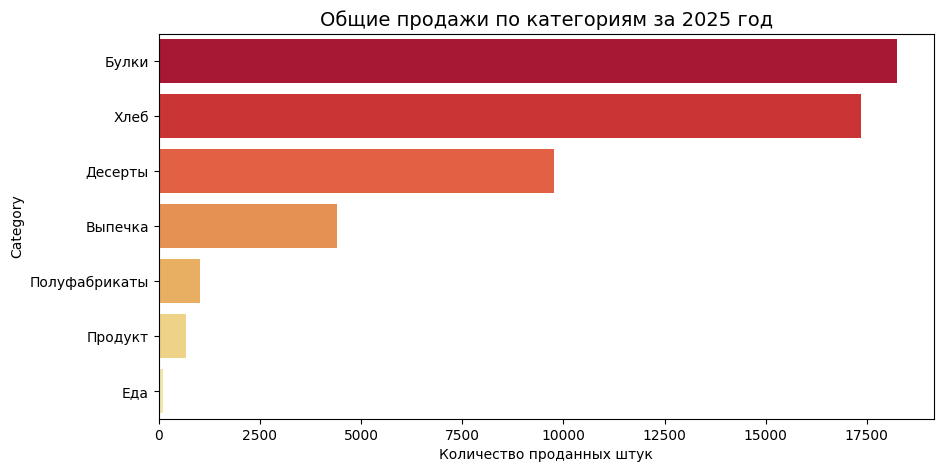

In [108]:
# Строим график объемов продаж по категориям товаров
plt.figure(figsize=(10, 5))
category_sales = df_2025.groupby('Category')['Count'].sum().sort_values(ascending=False)

sns.barplot(x=category_sales.values, y=category_sales.index, palette='YlOrRd_r')
plt.title('Общие продажи по категориям за 2025 год', fontsize=14)
plt.xlabel('Количество проданных штук')
plt.show()


In [109]:
# 1. Считаем общие продажи каждого товара за 2025 год
product_sales = df_2025.groupby(['Category', 'Name'])['Count'].sum().reset_index()

# 2. Магия Pandas: делим продажи товара на сумму продаж ВСЕЙ его категории (через transform)
product_sales['Доля_в_категории_%'] = (
    product_sales['Count'] / product_sales.groupby('Category')['Count'].transform('sum')
) * 100

# Сортируем для красоты: сначала по категориям, а внутри них — от лидеров к аутсайдерам
product_sales = product_sales.sort_values(['Category', 'Доля_в_категории_%'], ascending=[True, False])

print("--- ТОП-3 ТОВАРА ВНУТРИ КАЖДОЙ КАТЕГОРИИ (НОРМИРОВАНО) ---")
print(product_sales.groupby('Category').head(3).to_string(index=False))


--- ТОП-3 ТОВАРА ВНУТРИ КАЖДОЙ КАТЕГОРИИ (НОРМИРОВАНО) ---
     Category                                         Name  Count  Доля_в_категории_%
        Булки                              Булка с корицей 4003.0           21.947475
        Булки                           Булка с кардамоном 2583.0           14.161961
        Булки               Маритоццо ваниль-мисо карамель 2267.0           12.429410
      Выпечка                                 Круассан 75г 3660.0           83.181818
      Выпечка                           Honey butter toast  522.0           11.863636
      Выпечка                 Грушевый пирог со штрейзелем  122.0            2.772727
      Десерты                  Печенье на закваске шоколад 1999.0           20.462688
      Десерты                                        Канле 1648.0           16.869690
      Десерты        Кекс морковный с карамельной глазурью 1195.0           12.232572
          Еда Запеканка на рисовой муке без сахара в форме  101.0          100.00

<Figure size 1400x800 with 0 Axes>

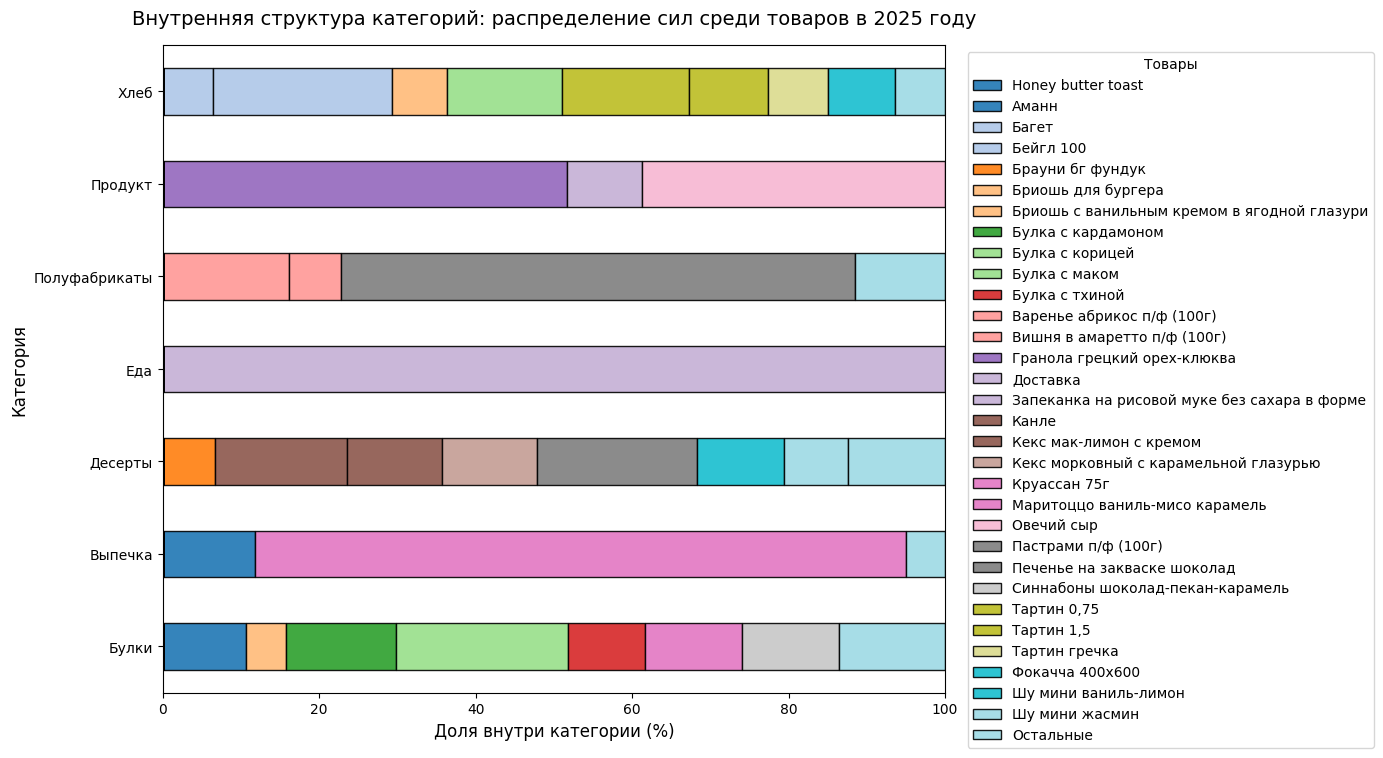

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Считаем продажи и доли товаров внутри категорий
prod_structure = df_2025.groupby(['Category', 'Name'])['Count'].sum().reset_index()
prod_structure['Share_%'] = (prod_structure['Count'] / prod_structure.groupby('Category')['Count'].transform('sum')) * 100

# 2. Схлопываем мелкие товары (< 5% внутри категории) в группу "Остальные", чтобы не было каши
prod_structure.loc[prod_structure['Share_%'] < 5, 'Name'] = 'Остальные'
pivot_structure = prod_structure.groupby(['Category', 'Name'])['Share_%'].sum().unstack().fillna(0)

# Сортируем колонки так, чтобы "Остальные" были в самом конце (на графике — на правом краю)
if 'Остальные' in pivot_structure.columns:
    cols = [c for c in pivot_structure.columns if c != 'Остальные'] + ['Остальные']
    pivot_structure = pivot_structure[cols]

# 3. Строим горизонтальный 100% график
# Используем большую качественную палитру для множества товаров
plt.figure(figsize=(14, 8))
pivot_structure.plot(kind='barh', stacked=True, figsize=(14, 8), cmap='tab20', edgecolor='black', alpha=0.9)

# Настраиваем оформление
plt.title('Внутренняя структура категорий: распределение сил среди товаров в 2025 году', fontsize=14, pad=15)
plt.xlabel('Доля внутри категории (%)', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.xlim(0, 100)

# Выносим легенду вправо, чтобы она не перекрывала график
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Товары")
plt.tight_layout()
plt.show()


C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\2474575528.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Count', y='Name', dodge=False, palette='flare')


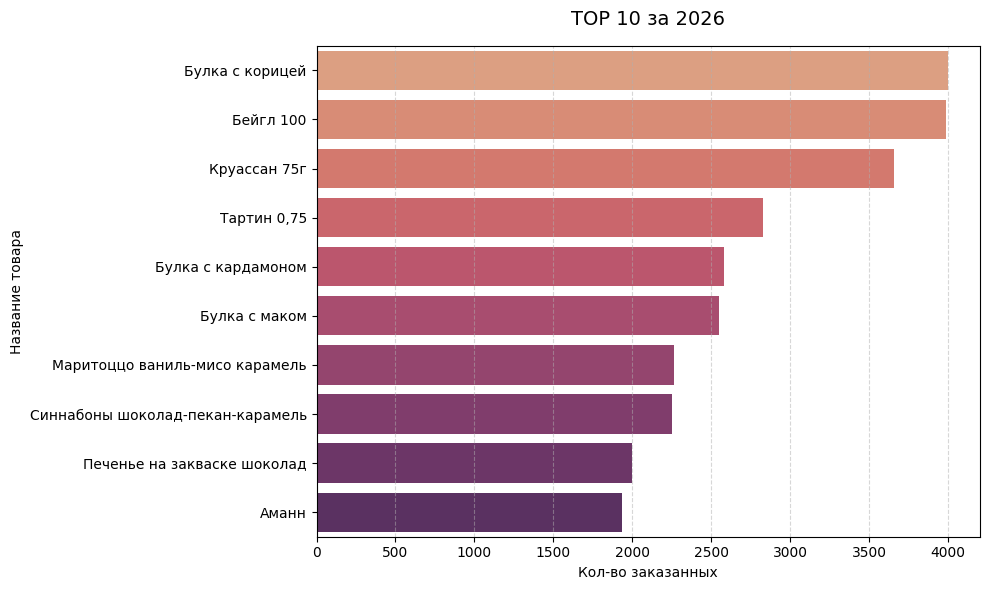

In [111]:
top_products = df_2025.groupby(['Category', 'Name'])['Count'].sum().reset_index()
top_products = top_products.sort_values(by='Count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='Count', y='Name', dodge=False, palette='flare')

plt.title('TOP 10 за 2026', fontsize=14, pad=15)
plt.xlabel('Кол-во заказанных')
plt.ylabel('Название товара')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [112]:
def plot_counts_in_category(target_category:str):
    category_df = df_2025[df_2025['Category'] == target_category] 
    product_count = category_df.groupby('Name')['Count'].sum().reset_index().sort_values(by='Count', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')

    plt.title(f'Кол-во товаров в категории "{target_category}"', fontsize=14, pad=15)
    plt.xlabel('Кол-во заказанных')
    plt.ylabel(None)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\1000321327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


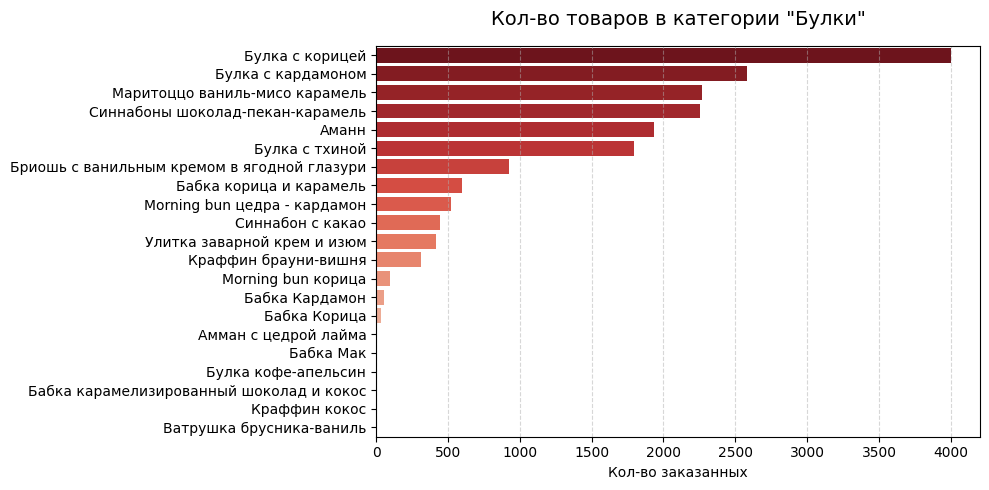

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\1000321327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


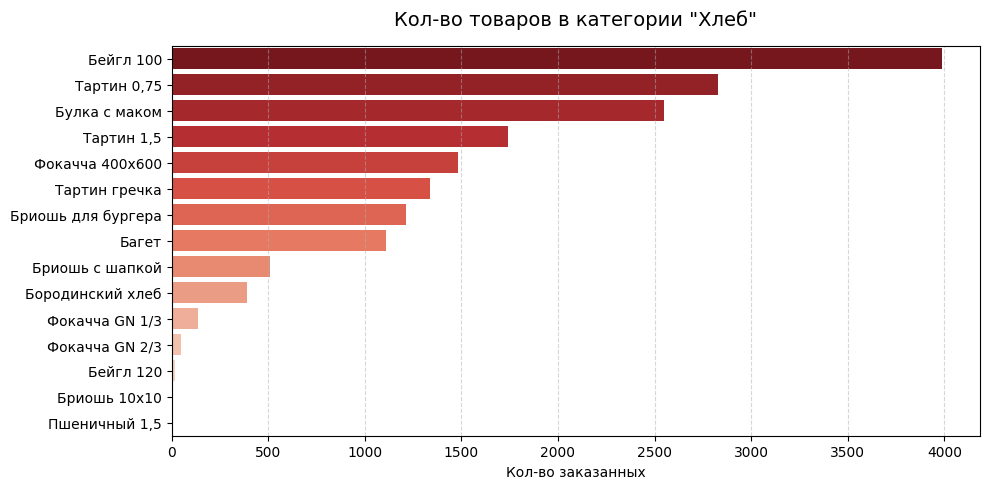

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\1000321327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


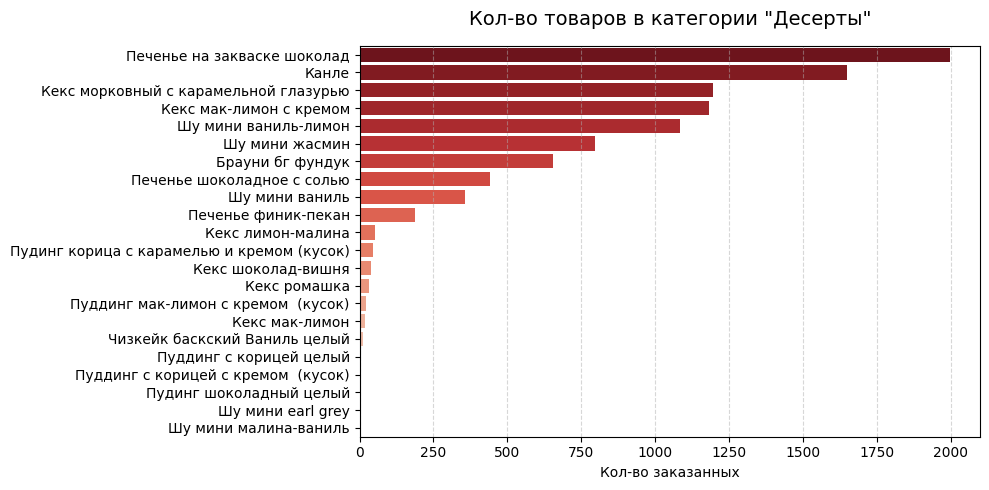

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\1000321327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


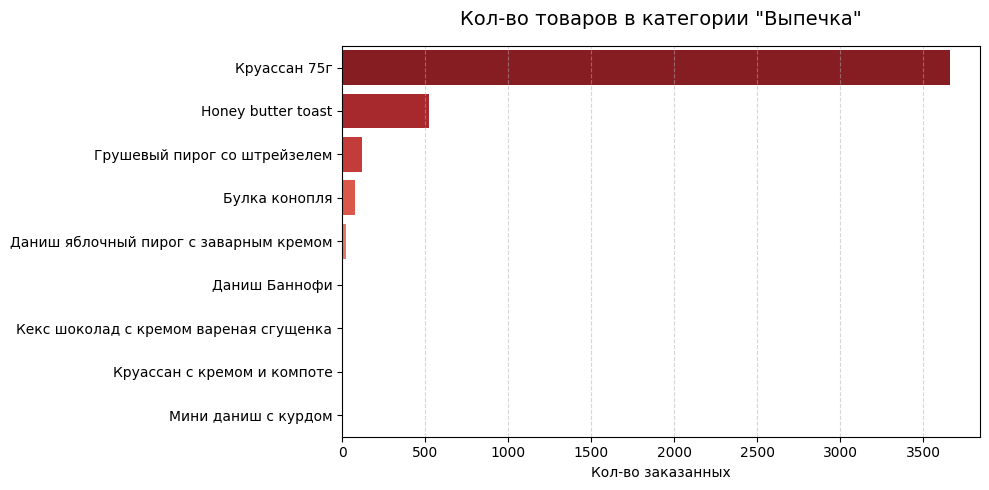

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\1000321327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


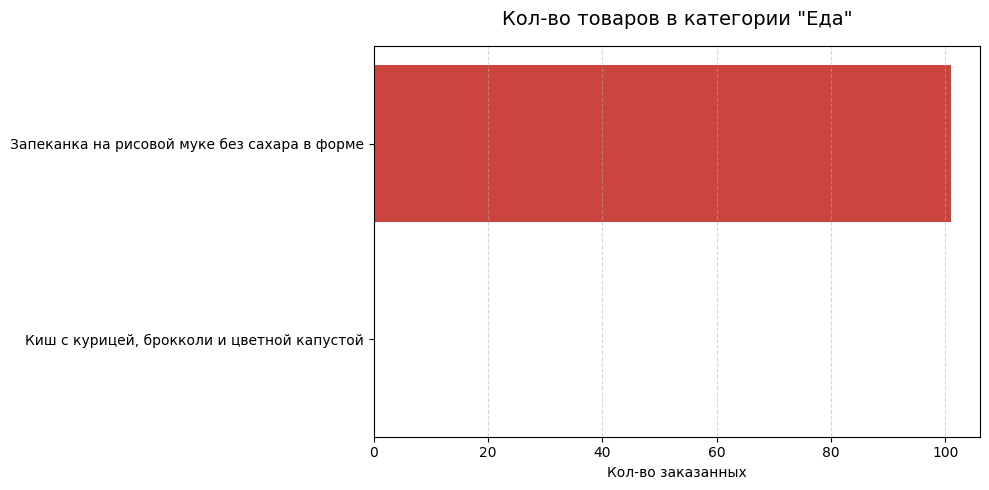

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\1000321327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


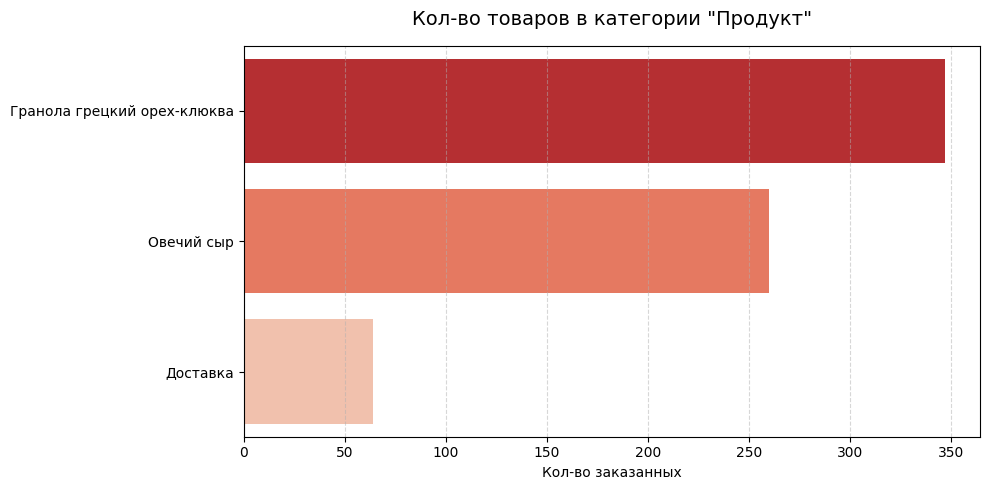

C:\Users\S_V_Nikitin\AppData\Local\Temp\ipykernel_8416\1000321327.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_count, x='Count', y='Name', palette='Reds_r')


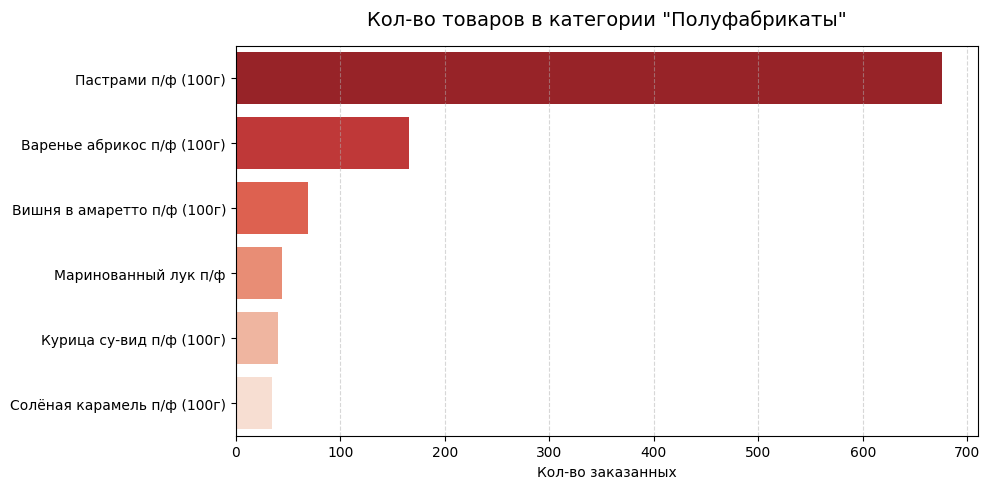

In [113]:
for category in df_2025['Category'].unique():
    plot_counts_in_category(category)

In [114]:
total_count = df_2025.groupby(['Category', 'Name'])['Count'].sum().reset_index()
top_3_per_cat = total_count.sort_values(['Category','Count'], ascending=[True, False]).groupby('Category').head(3)
pd.set_option('display.max_rows', None)
top_3_per_cat.reset_index(drop=True)

,Category,Name,Count
0,Булки,Булка с корицей,4003.0
1,Булки,Булка с кардамоном,2583.0
2,Булки,Маритоццо ваниль-мисо карамель,2267.0
3,Выпечка,Круассан 75г,3660.0
4,Выпечка,Honey butter toast,522.0
5,Выпечка,Грушевый пирог со штрейзелем,122.0
6,Десерты,Печенье на закваске шоколад,1999.0
7,Десерты,Канле,1648.0
8,Десерты,Кекс морковный с карамельной глазурью,1195.0
9,Еда,Запеканка на рисовой муке без сахара в форме,101.0


In [115]:
pd.reset_option('display.max_rows')

In [116]:
sales_2025 = df_2025.groupby(['Category', 'Name'])['Count'].sum().reset_index()
sales_2025.rename(columns={'Count': 'Sales_2025'}, inplace=True)

In [117]:
sales_2025.to_csv('sales_2025_ready.csv', index=False)

In [118]:
df_2025.to_csv('raw_2025.csv', index=False)